# Experiment 1 — Small Composed Model: Correlated Feature Amplitudes

Train the 4-input, 2-hidden-dimensional ReLU toy model when the two active features always have identical magnitudes. The model stores anticorrelated true features in antipodal directions. SAELens `StandardTrainingSAE` is used for training.

**Important:** correlated amplitudes do not mean both active values are fixed at 1. Every sample selects one feature from `(x1, x2)` and one from `(y1, y2)`, then assigns both selected features the same random amplitude from $U[0,1)$.

## 1. Setup

`FULL_RUN=False` uses reduced training sizes for a fast, inspectable run. `FULL_RUN=True` uses 10,000 toy-model batches and 128,000,000 SAE samples. The 5×5 grid is separately gated because it trains multiple SAEs at every grid point.

In [1]:
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from sae import (
    DEFAULT_SAE_SEEDS, FULL_SAE_TRAINING, GRID_L1_COEFFICIENTS,
    GRID_LEARNING_RATES, SAETrainingConfig, load_sae, save_sae, train_sae,
    train_sae_grid,
)
from toy_model import (
    FULL_TOY_TRAINING, ToyTrainingConfig, default_device, load_toy_model,
    make_correlated_amplitude_model, save_toy_model, train_toy_model,
)
from visualization import (
    evaluate_sae, plot_feature_batch, plot_geometry, plot_sae_grid,
    plot_sae_matrices, plot_training_loss, select_best_sae,
)

FULL_RUN = True
RUN_GRID = False
DEVICE = default_device()
ARTIFACTS = Path('artifacts')
ARTIFACTS.mkdir(exist_ok=True)
print(f'Using {DEVICE}')

Using mps


In [2]:
if FULL_RUN:
    toy_training = FULL_TOY_TRAINING
    sae_training = FULL_SAE_TRAINING
    primary_seeds = DEFAULT_SAE_SEEDS
else:
    toy_training = ToyTrainingConfig(batches=500, batch_size=512, seed=0)
    sae_training = SAETrainingConfig(
        training_samples=100_000, batch_size=512, lr=3e-4,
        l1_coefficient=0.3, seed=0,
    )
    primary_seeds = (0,)

toy_training, sae_training, primary_seeds

(ToyTrainingConfig(batches=10000, batch_size=1000, lr=0.001, weight_decay=0.01, seed=0),
 SAETrainingConfig(d_sae=4, training_samples=128000000, batch_size=1024, lr=0.0003, l1_coefficient=0.3, seed=0, lr_warm_up_steps=0, lr_decay_steps=0, adam_beta1=0.0, adam_beta2=0.999, apply_b_dec_to_input=False),
 (0, 1))

## 2. Inspect the composed-feature sampler

The probability table is uniform over the four pairs `(x1,y1)`, `(x1,y2)`, `(x2,y1)`, and `(x2,y2)`. `active_features_per_draw=1` means one pair per sample; it does not mean an amplitude of 1.

Probability table:
 tensor([[0.2500, 0.2500],
        [0.2500, 0.2500]], device='mps:0')
First eight samples:
 tensor([[0.8762, 0.0000, 0.8762, 0.0000],
        [0.0000, 0.6182, 0.6182, 0.0000],
        [0.0000, 0.9848, 0.0000, 0.9848],
        [0.4189, 0.0000, 0.4189, 0.0000],
        [0.0000, 0.1368, 0.1368, 0.0000],
        [0.0000, 0.2050, 0.0000, 0.2050],
        [0.0600, 0.0000, 0.0600, 0.0000],
        [0.3684, 0.0000, 0.3684, 0.0000]])
Maximum sampled amplitude: 0.9997649788856506


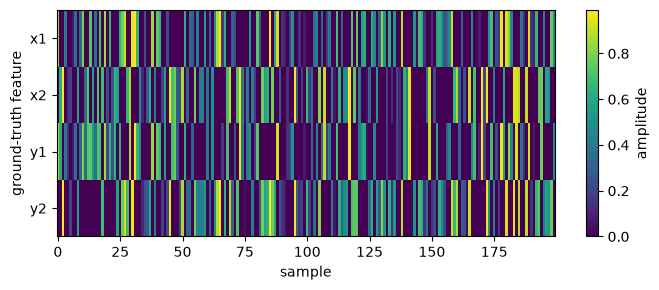

In [3]:
model = make_correlated_amplitude_model(toy_training, device=DEVICE)
feature_batch = model.get_batch(2_000)

assert torch.all((feature_batch[:, :2] > 0).sum(dim=1) == 1)
assert torch.all((feature_batch[:, 2:] > 0).sum(dim=1) == 1)
assert torch.allclose(feature_batch[:, :2].sum(1), feature_batch[:, 2:].sum(1))

print('Probability table:\n', model.get_prob_table())
print('First eight samples:\n', feature_batch[:8].cpu())
print('Maximum sampled amplitude:', feature_batch.max().item())
plot_feature_batch(feature_batch);

## 3. Train the tied-weight toy model

The four input features are compressed into two hidden dimensions and reconstructed through tied weights. Training minimizes importance-weighted mean squared error with AdamW.

In [4]:
toy_checkpoint = ARTIFACTS / ('toy_model_full.pt' if FULL_RUN else 'toy_model_quick.pt')
if toy_checkpoint.exists():
    load_toy_model(model, toy_checkpoint)
    toy_losses = []
    print('Loaded', toy_checkpoint)
else:
    toy_losses = train_toy_model(model, toy_training)
    save_toy_model(model, toy_checkpoint)
    print('Saved', toy_checkpoint)

if toy_losses:
    plot_training_loss(toy_losses);

Loaded artifacts/toy_model_full.pt


## 4. Train SAELens SAE(s)

Each configured seed trains an independent SAELens model. SAELens owns the standard ReLU SAE, L1 loss, normalization constraints, optimizer, trainer, and checkpoint format. Decoder bias subtraction is disabled at the encoder input.

In [5]:
primary_saes = []
for seed in primary_seeds:
    run_cfg = replace(sae_training, seed=seed)
    run_dir = ARTIFACTS / f'primary_sae_{"full" if FULL_RUN else "quick"}_seed{seed}'
    if (run_dir / 'cfg.json').exists():
        sae = load_sae(run_dir, device=DEVICE)
        print('Loaded', run_dir)
    else:
        sae = train_sae(model, run_cfg, device=DEVICE)
        save_sae(sae, run_dir)
        print('Saved', run_dir)
    primary_saes.append(sae)

Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/primary_sae_full_seed0


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

Saved artifacts/primary_sae_full_seed1


## 5. Evaluate and visualize

The plots compare ground-truth toy-model directions, SAE decoder directions, decoder cosine similarity, and SAE responses to individual data features.

seed 0: {'mse': 0.02096790261566639, 'normalized_mse': 0.21431899070739746, 'mean_l0': 0.8986999988555908, 'mean_l1': 0.5867056846618652}
seed 1: {'mse': 0.020974276587367058, 'normalized_mse': 0.2079818844795227, 'mean_l0': 0.8986999988555908, 'mean_l1': 0.5459890961647034}


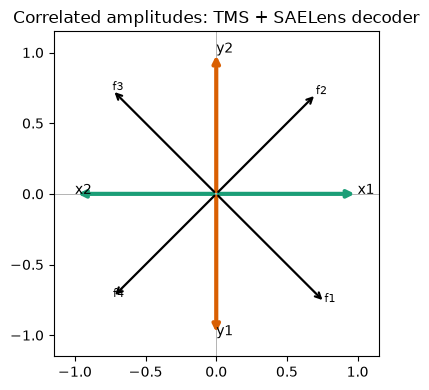

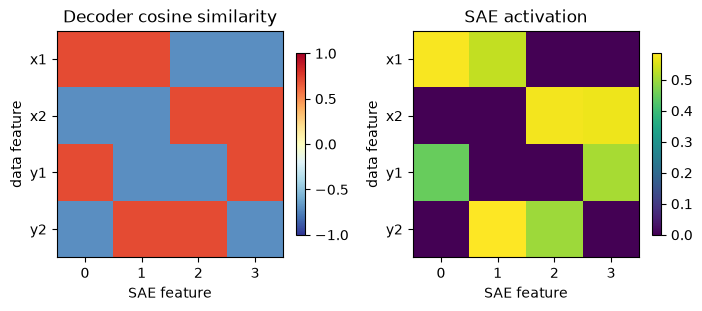

In [6]:
for seed, sae in zip(primary_seeds, primary_saes):
    print(f'seed {seed}:', evaluate_sae(model, sae, samples=10_000))

best_sae = select_best_sae(model, primary_saes, samples=10_000)
plot_geometry(model, best_sae, title='Correlated amplitudes: TMS + SAELens decoder');
plot_sae_matrices(model, best_sae);

## 6. Optional 5×5 SAE grid

The grid varies learning rate and L1 coefficient for correlated feature amplitudes. With `FULL_RUN=True`, every setting uses 128M samples and trains one independent SAE for each configured seed.

In [ ]:
if RUN_GRID:
    grid_base = sae_training if FULL_RUN else replace(sae_training, training_samples=50_000)
    grid_seeds = DEFAULT_SAE_SEEDS if FULL_RUN else (0,)
    grid_results = train_sae_grid(
        model, grid_base, learning_rates=GRID_LEARNING_RATES,
        l1_coefficients=GRID_L1_COEFFICIENTS, seeds=grid_seeds,
        device=DEVICE,
    )
    plot_sae_grid(
        model, grid_results, GRID_LEARNING_RATES, GRID_L1_COEFFICIENTS
    );
else:
    print('Grid skipped. Set RUN_GRID = True to run it.')

## Experiment 1 files

- `toy_model.py`: model configuration, tied-weight network, correlated-pair sampler, training, and checkpoints.

- `sae.py`: hidden-activation iterator, SAELens configuration and training, parameter grid, and checkpoints.

- `visualization.py`: evaluation metrics and Experiment 1 plots.
- SAELens provides the SAE architecture, loss, training mechanics, and native save/load.